In [ ]:
!pip install numpy pandas matplotlib ucimlrepo ipywidgets plotly


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [149]:
# importy
import pandas as pd
import matplotlib.pyplot as plt

### Zadanie 1


0: https://www.kaggle.com/datasets/jillanisofttech/iris-dataset-uci


In [150]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
Y = iris.data.targets

# metadata
print(iris.metadata)

# variable information
print(iris.variables)

{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

In [151]:
iris

{'data': {'ids': None,
  'features':      sepal length  sepal width  petal length  petal width
  0             5.1          3.5           1.4          0.2
  1             4.9          3.0           1.4          0.2
  2             4.7          3.2           1.3          0.2
  3             4.6          3.1           1.5          0.2
  4             5.0          3.6           1.4          0.2
  ..            ...          ...           ...          ...
  145           6.7          3.0           5.2          2.3
  146           6.3          2.5           5.0          1.9
  147           6.5          3.0           5.2          2.0
  148           6.2          3.4           5.4          2.3
  149           5.9          3.0           5.1          1.8
  
  [150 rows x 4 columns],
  'targets':               class
  0       Iris-setosa
  1       Iris-setosa
  2       Iris-setosa
  3       Iris-setosa
  4       Iris-setosa
  ..              ...
  145  Iris-virginica
  146  Iris-virginica
  147  

Dataset zawiera pomiary 150 kwiatów. (50 po kazdej z 3 klas).
Trzyma informacje:
sepal length, sepal width
petal length, petal width
(działka kilicha i płatek kielicha)

In [152]:
print("Statystyki dla sepal length")
print(X['sepal length'].describe())

Statystyki dla sepal length
count    150.000000
mean       5.843333
std        0.828066
min        4.300000
25%        5.100000
50%        5.800000
75%        6.400000
max        7.900000
Name: sepal length, dtype: float64


mean -> średnia arytmetyczna
std -> odchylenie standardowe (miara rozproszenia danych wokół średniej)
min/max -> wartość minimalna/maksymalna
k% -> k% najmniejszych obserwacji

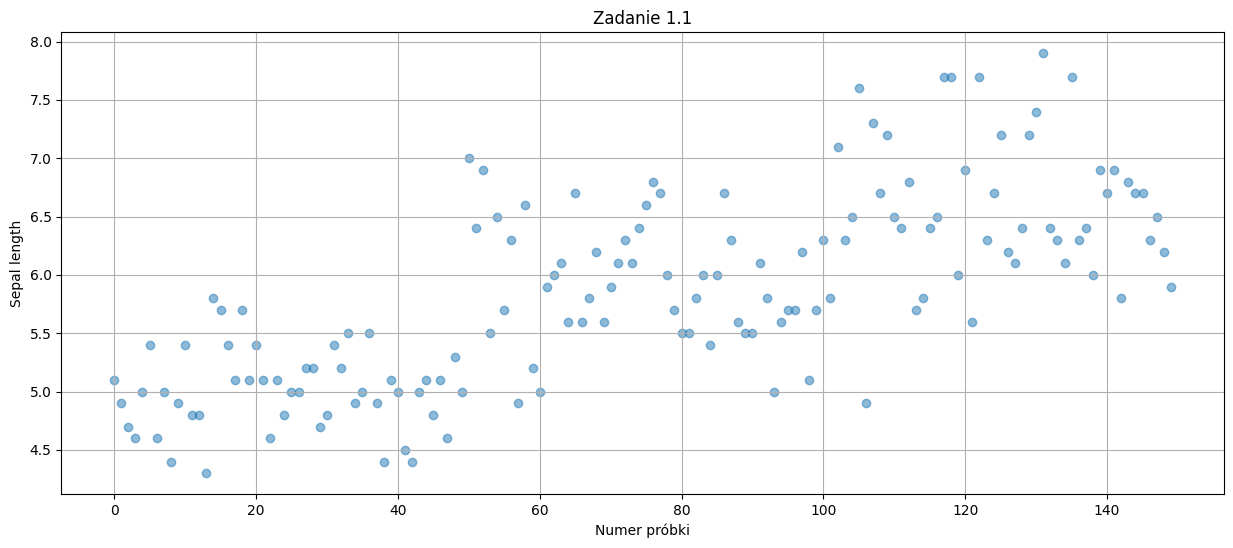

In [153]:
plt.figure(figsize=(15, 6)) # rozmiar wykresu
plt.scatter(X.index, X['sepal length'], alpha=0.5)
plt.xlabel("Numer próbki")
plt.ylabel("Sepal length")
plt.title("Zadanie 1.1")
plt.grid(True) # siatka dla lepszej orientacji
plt.show()


Nie ma sensu łączyć kropki. Nie ma żadnego porządku tutaj kolejność próbek w zbiorze jest przypadkowa.

zadanie 1.2

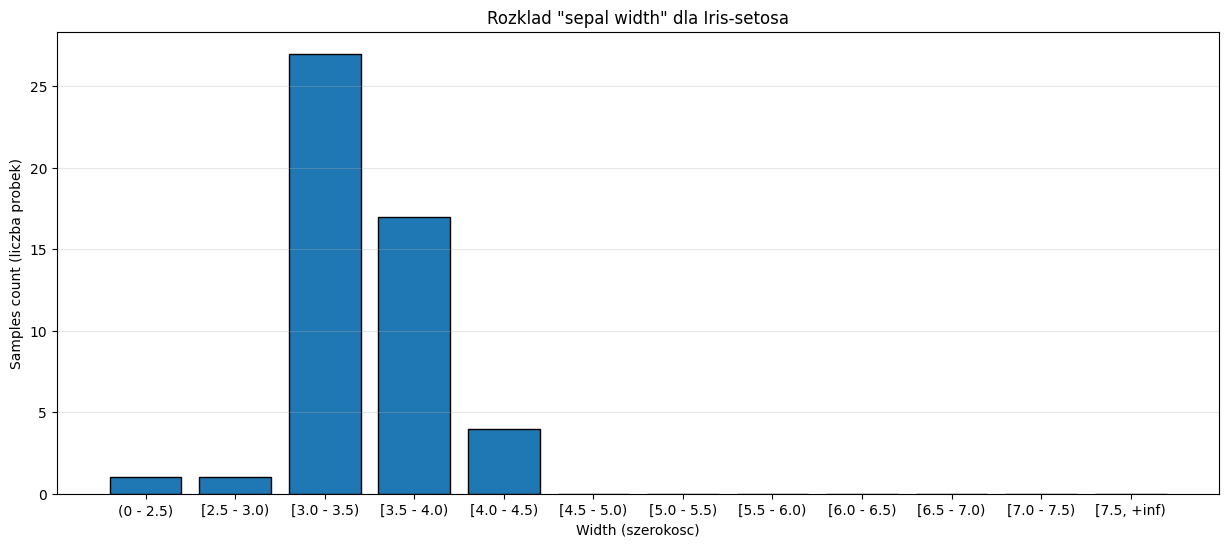

In [154]:
k1 = 0 # < 2.5
k2 = 0 # 2.5 - 3.0
k3 = 0 # 3.0 - 3.5
k4 = 0 # 3.5 - 4.0
k5 = 0 # 4.0 - 4.5
k6 = 0 # 4.5 - 5.0
k7 = 0 # 5.0 - 5.5 ...
k8, k9, k10, k11, k12 = 0, 0, 0, 0, 0
setosa_sepal_widths = []
for i in range(len(X)):
    if Y['class'][i] == 'Iris-setosa':
        setosa_sepal_widths.append(X['sepal width'][i])

for w in setosa_sepal_widths:
    w = float(w)
    k1 += (w < 2.5)
    k2 += (2.5 <= w < 3.0)
    k3 += (3.0 <= w < 3.5)
    k4 += (3.5 <= w < 4.0)
    k5 += (4.0 <= w < 4.5)
    k6 += (4.5 <= w < 5.0)
    k7 += (5.0 <= w < 5.5)
    k8 += (5.5 <= w < 6.0)
    k9 += (6.0 <= w < 6.5)
    k10 += (6.5 <= w < 7.0)
    k11 += (7.0 <= w < 7.5)
    k12 += (7.5 <= w < 8.0)

labels = ['(0 - 2.5)', '[2.5 - 3.0)', '[3.0 - 3.5)', '[3.5 - 4.0)', '[4.0 - 4.5)', '[4.5 - 5.0)', '[5.0 - 5.5)', '[5.5 - 6.0)', '[6.0 - 6.5)', '[6.5 - 7.0)', '[7.0 - 7.5)', '[7.5, +inf)']
counts = [k1, k2, k3, k4, k5, k6, k7, k8, k9, k10, k11, k12]

plt.figure(figsize=(15, 6))
plt.bar(labels, counts, color='C0', edgecolor='k')
plt.xlabel('Width (szerokosc)')
plt.ylabel('Samples count (liczba probek)')
plt.title('Rozklad "sepal width" dla Iris-setosa')
plt.grid(alpha=0.3, axis='y')
plt.show()
# tak. to jest histogram


zadanie 1.3

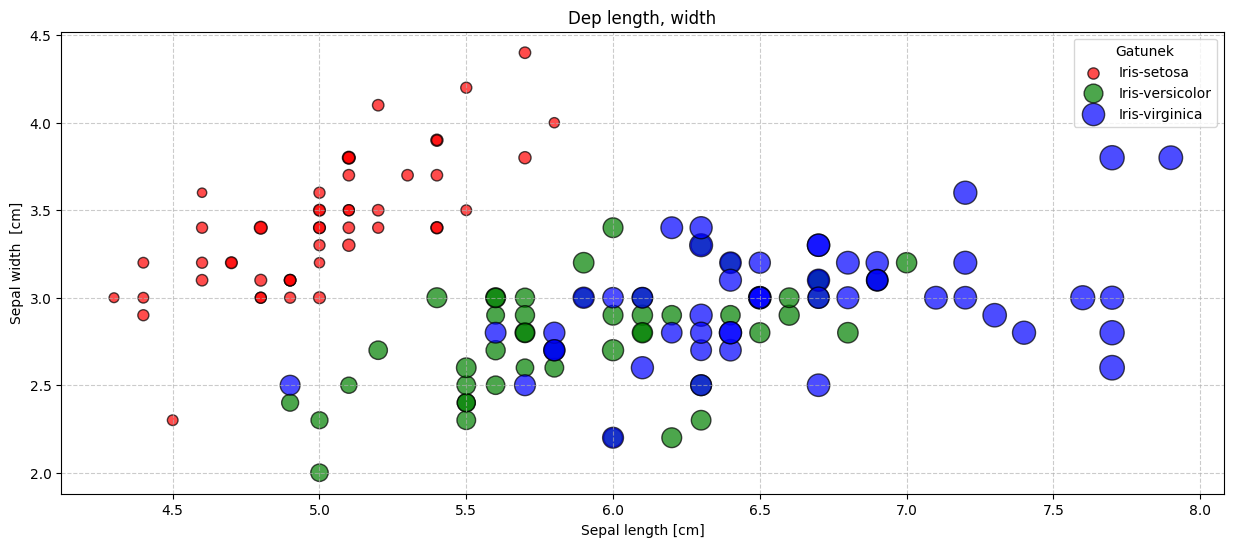

In [155]:
df = pd.concat([X,Y], axis = 1) # jeden dataframe dla wygody
colors = {'Iris-setosa' : 'red',
         'Iris-versicolor' : 'green',
         'Iris-virginica' : 'blue'
         }

plt.figure(figsize=(15, 6))

for g in df['class'].unique():
    subset = df[df['class'] == g]
    plt.scatter(
        subset['sepal length'],
        subset['sepal width'],
        s=subset['petal length']*45, # dla widocznosci
        c=colors[g],
        alpha=0.7,
        edgecolor='k',
        label = g
)

plt.xlabel('Sepal length [cm]')
plt.ylabel('Sepal width  [cm]')
plt.title('Dep length, width')
plt.legend(title="Gatunek")
plt.grid(True, linestyle='--', alpha=0.65)
plt.show()


Nie łączymy kropek. Każda kropka to pomiar jednego kwiatka. Nie ma między nimi żadnej zależności.
Widzimy odrębność Iris-setosa (te czerwone), tworzą osobny klaster. Charakteryzują się dużą szerokością i małą długością.
Zielone kropki i niebieskie nachodzą na siebie.
Można łatwo odróżnić Iris-setosa od pozostałych gatunków

zadanie 1.4

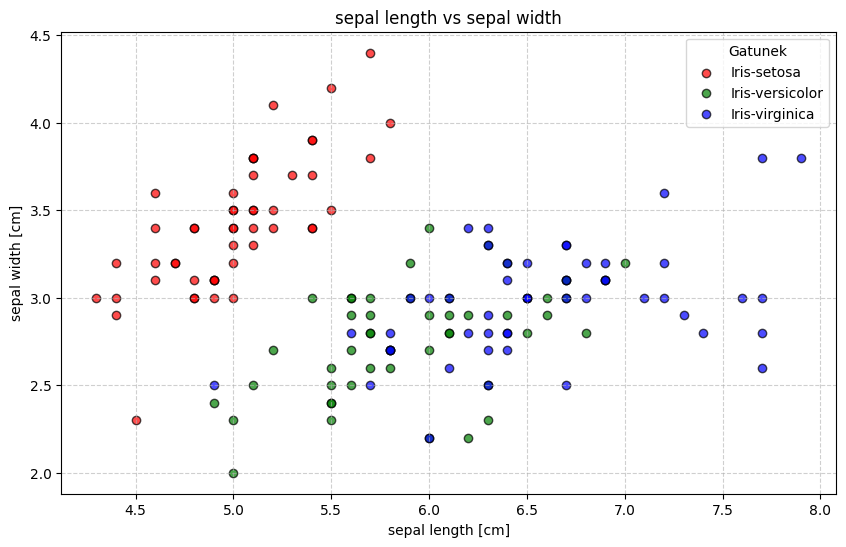

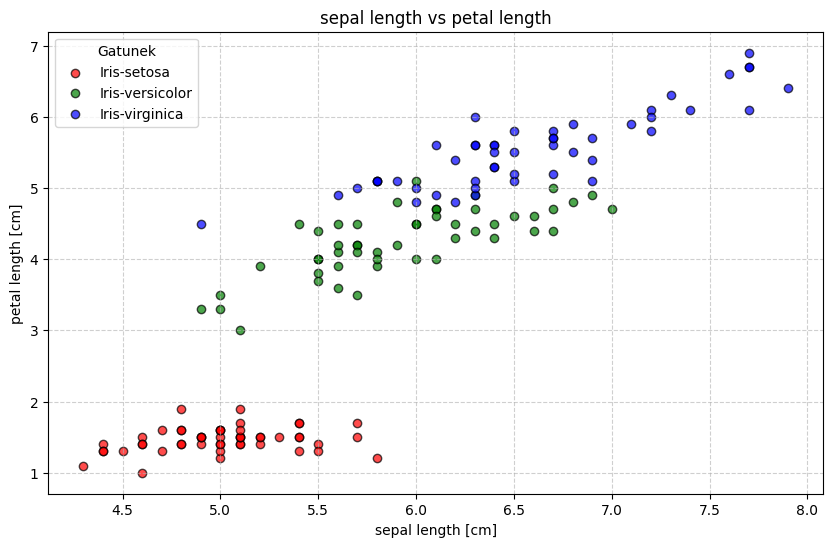

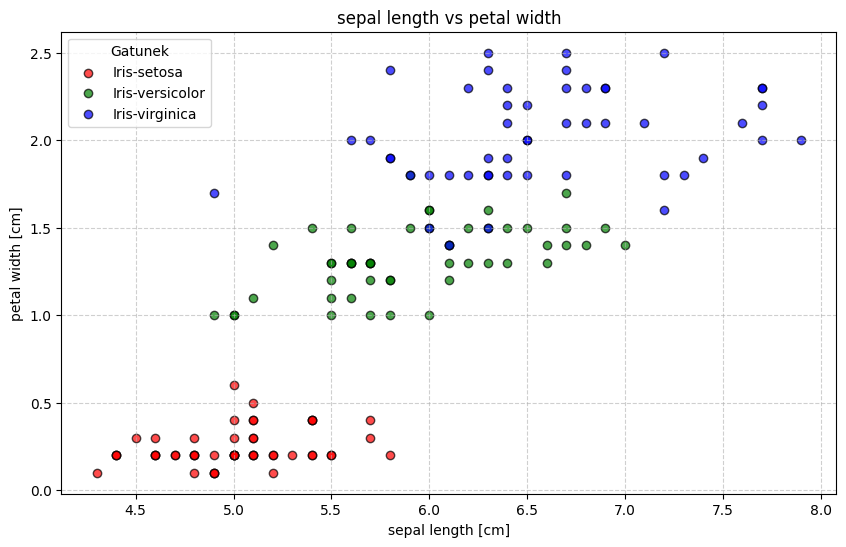

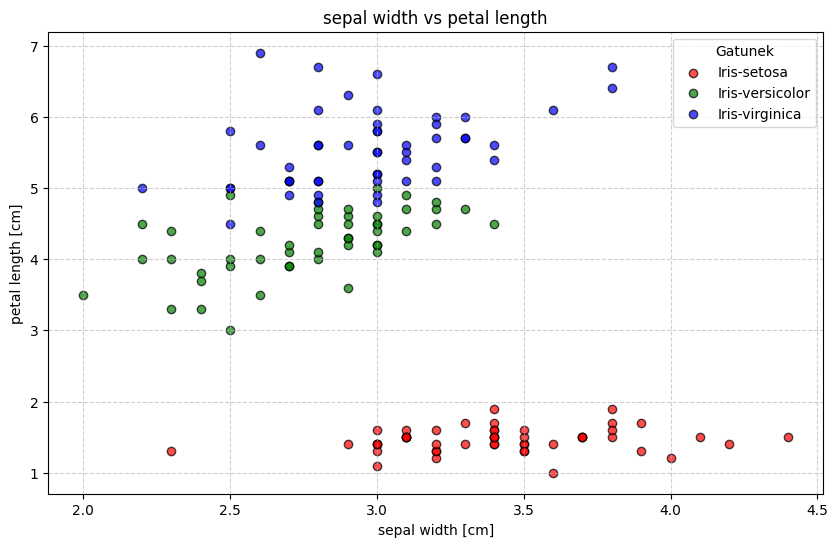

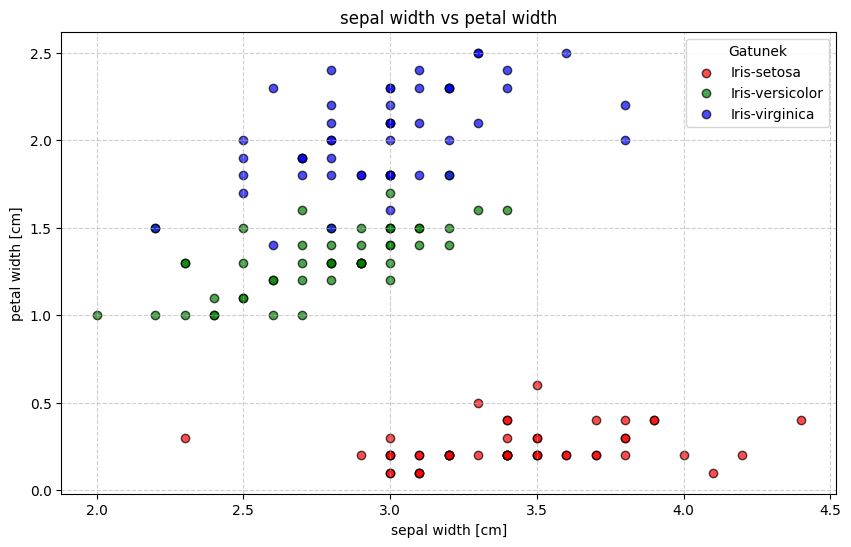

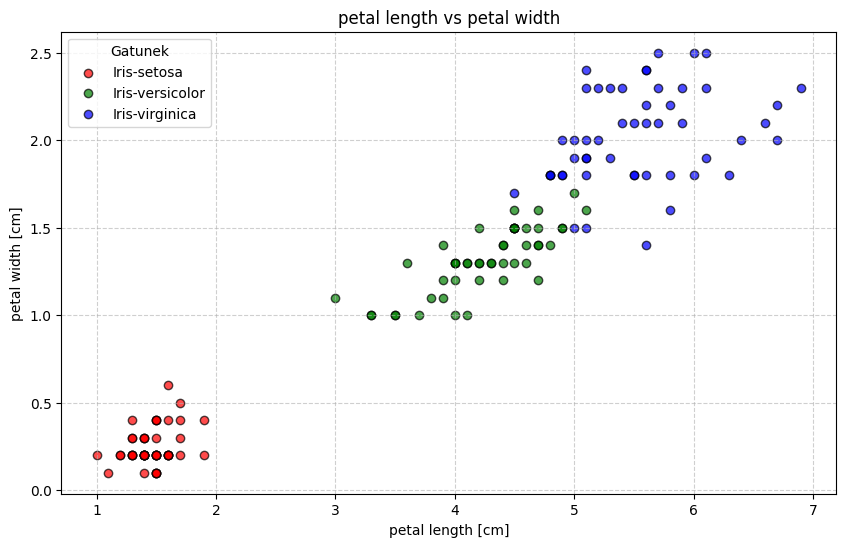

In [156]:
df = pd.concat([X, Y], axis=1)
colors = {
    'Iris-setosa': 'red',
    'Iris-versicolor': 'green',
    'Iris-virginica': 'blue'
}

atrb = ['sepal length', 'sepal width', 'petal length', 'petal width']
pairs = []
for i in range(len(atrb)):
    for j in range(i+1, len(atrb)):
        pairs.append((atrb[i], atrb[j]))


for a1, a2 in pairs:
    plt.figure(figsize=(10, 6))
    for g in df['class'].unique():
        subset = df[df['class'] == g]
        plt.scatter(
            subset[a1],
            subset[a2],
            c=colors[g],
            label=g,
            alpha=0.7,
            edgecolor='k'
        )

    plt.xlabel(a1 + ' [cm]')
    plt.ylabel(a2 + ' [cm]')
    plt.title(f'{a1} vs {a2}')
    plt.legend(title='Gatunek')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.show()

zadanie 1.5

Wykres skrzypcowy --> taki wygladzony histogram. Szerokosc mowi, jak duzo punktow danych ma konkretną wartość.
Im szersza tym wiecej.

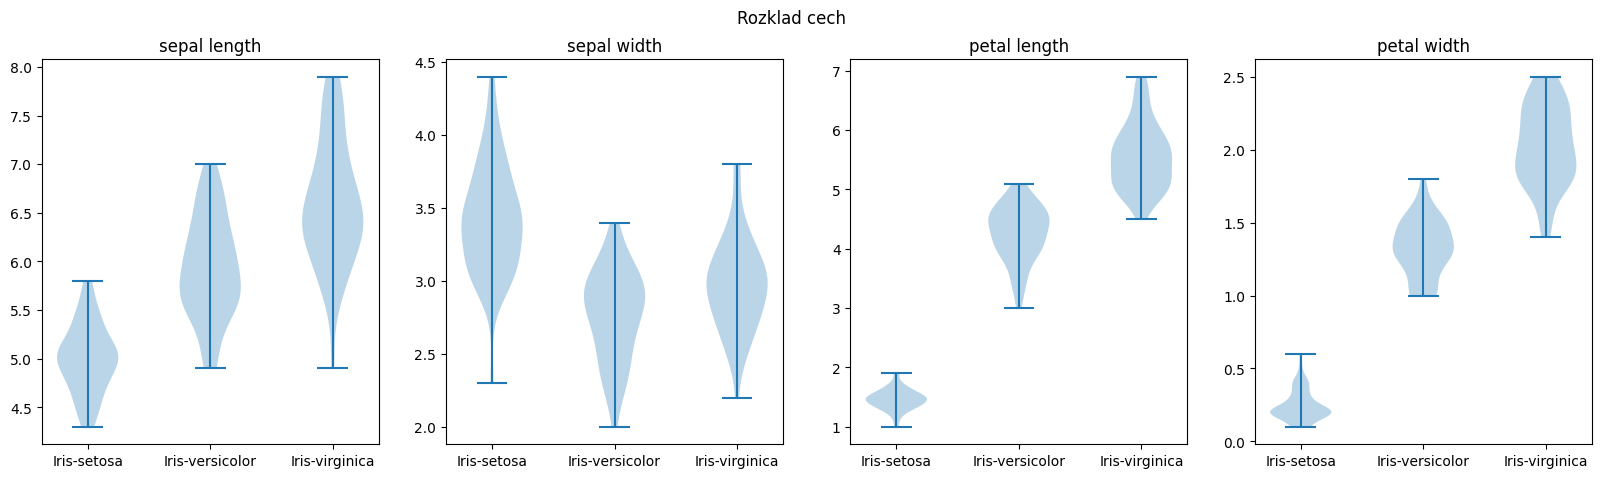

In [157]:
ug = df['class'].unique() # unique gatunki
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, a in enumerate(atrb):
    ax = axes[i]
    data_to_plot = [df[df['class'] == g][a] for g in ug]
    parts = ax.violinplot(data_to_plot)
    ax.set_title(a)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(ug)
fig.suptitle('Rozklad cech')

plt.show()

### Zadanie 2

In [158]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
Y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)


{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

,,The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y)."

zadanie 2.1

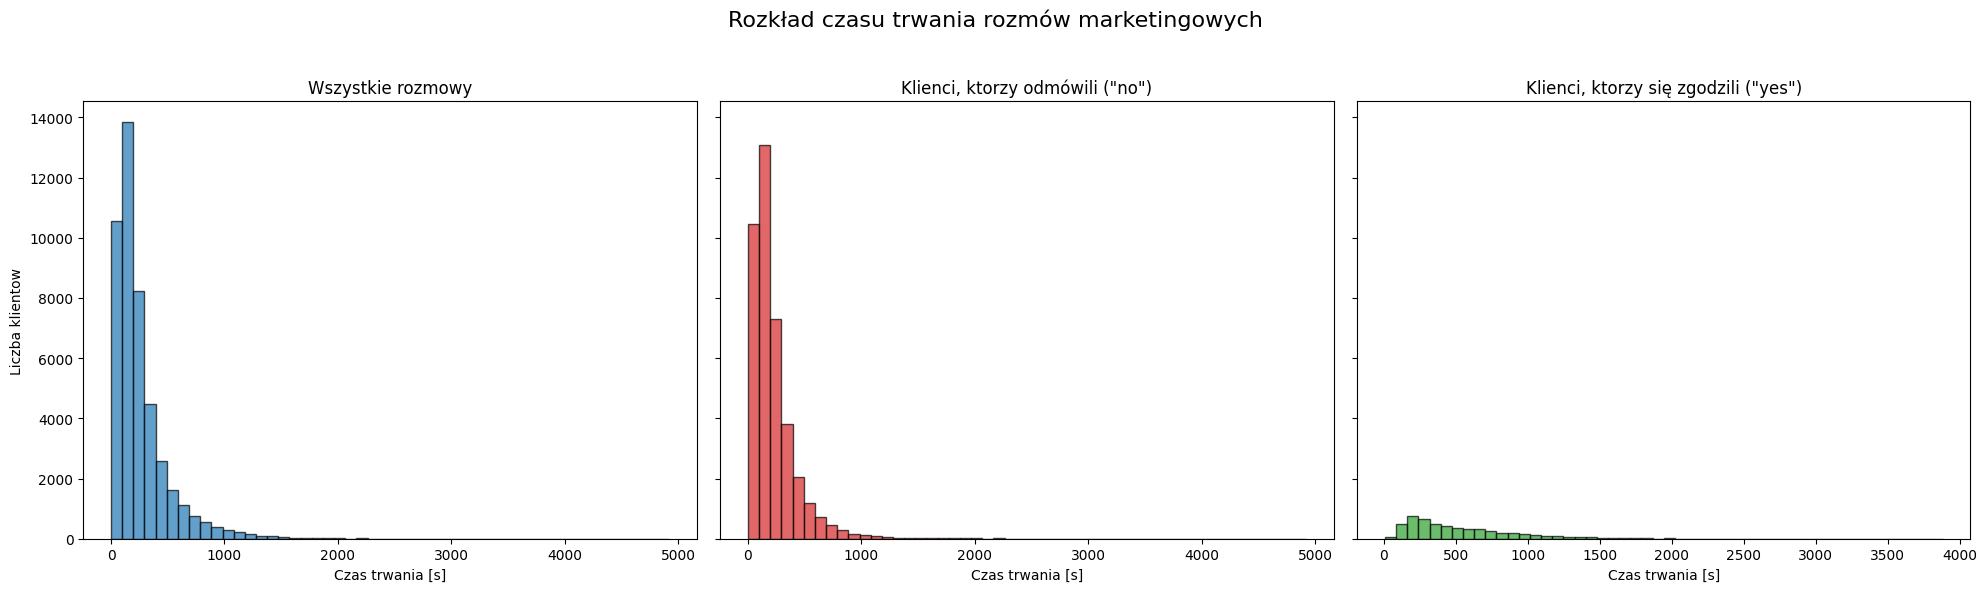

In [159]:
df = pd.concat([X, Y], axis = 1)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
# 1 siatka, 3 kolumny

# --- 1. Histogram dla wszystkich danych ---
axes[0].hist(df['duration'], bins=50, color='C0', edgecolor='k', alpha=0.7)
axes[0].set_title('Wszystkie rozmowy')
axes[0].set_xlabel('Czas trwania [s]')
axes[0].set_ylabel('Liczba klientow')

# --- 2. Histogram dla tych co odmowili ---
axes[1].hist(df[df['y'] == 'no']['duration'], bins=50, color='C3', edgecolor='k', alpha=0.7)
axes[1].set_title('Klienci, ktorzy odmówili ("no")')
axes[1].set_xlabel('Czas trwania [s]')

# --- 3. Histogram dla tych co sie zgodzili ---
axes[2].hist(df[df['y'] == 'yes']['duration'], bins=50, color='C2', edgecolor='k', alpha=0.7)
axes[2].set_title('Klienci, ktorzy się zgodzili ("yes")')
axes[2].set_xlabel('Czas trwania [s]')

fig.suptitle('Rozkład czasu trwania rozmów marketingowych', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [160]:
# dodatkowe staty
avg_total = df['duration'].mean()
avg_no = df[df['y'] == 'no']['duration'].mean()
avg_yes = df[df['y'] == 'yes']['duration'].mean()

print(f"Avg czas z wszystkich rozmów: {avg_total:.2f} s")
print(f"Avg czas z odmową ('no'): {avg_no:.2f} s")
print(f"Avg czas ze zgodą ('yes'): {avg_yes:.2f} s")


Avg czas z wszystkich rozmów: 258.16 s
Avg czas z odmową ('no'): 221.18 s
Avg czas ze zgodą ('yes'): 537.29 s


krótkie rozmowy to głównie odmowy. te dłuższę statystycznie konczą się sukcesem.

zadanie 2.2

In [161]:
import ipywidgets as widgets
from ipywidgets import interact

In [162]:
from pandas import describe_option


def plot_interactive_histogram(age_limit):
    fltr_df =df[df['age'] > age_limit]
    plt.figure(figsize=(12, 7))
    plt.hist(fltr_df['balance'], bins=100, color='C4', edgecolor='k', alpha=0.8)
    plt.title(f'Rozklad salda na koncie dla klientow w wieku > {age_limit} lat')
    plt.xlabel('Saldo na koncie')
    plt.ylabel('Liczba klientow')
    plt.grid(True, linestyle='--', alpha=0.8)
    plt.show()

interact(
    plot_interactive_histogram,
    age_limit=widgets.IntSlider(min=18, max=90, step=1, value=25, description='Wiek >')
)

interactive(children=(IntSlider(value=25, description='Wiek >', max=90, min=18), Output()), _dom_classes=('wid…

<function __main__.plot_interactive_histogram(age_limit)>

Zadanie 2.3

In [163]:
t = 360
long = df[df['duration'] > t]
succ = long[long['y'] == 'yes']
perc = (len(succ) / len(long)) * 100
print(f'{perc:.2f}% to probki pozytywne dla rozmow powyzej {t} sekund')

32.56% to probki pozytywne dla rozmow powyzej 360 sekund


In [164]:
import numpy as np

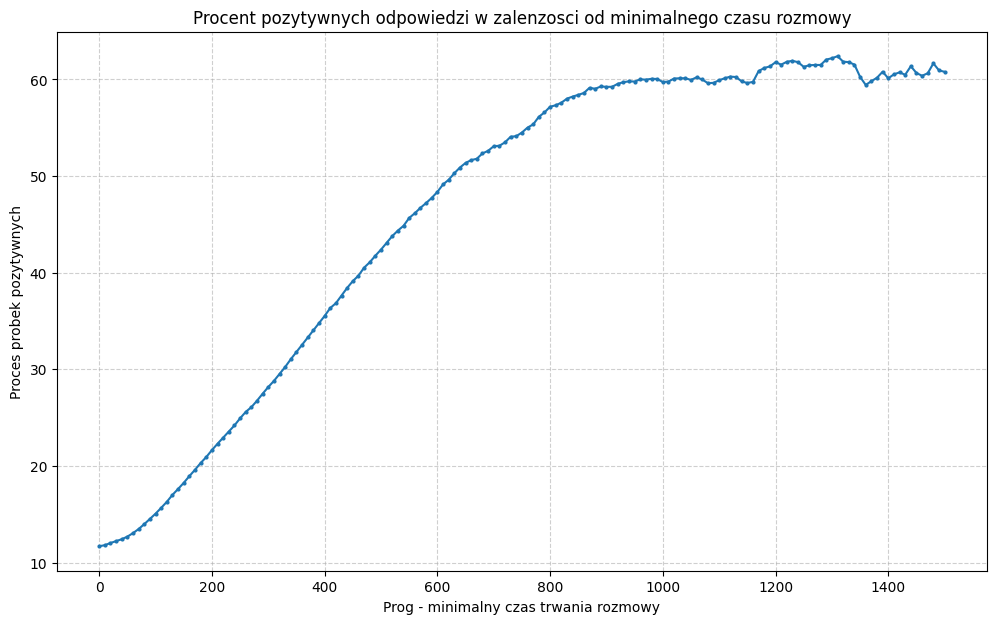

In [165]:
thr = np.arange(0, 1501, 10) # 0 do 1500 co 10 sec
perc = []

for t in thr:
    long = df[df['duration'] > t]
    if(len(long) > 0):
        succ = long[long['y'] == 'yes']
        prc = (len(succ) / len(long)) * 100
        perc.append(prc)
    else:
        perc.append(np.nan) # not a number

plt.figure(figsize=(12, 7))
plt.plot(thr, perc, marker='.', linestyle='-', markersize=4)
plt.title('Procent pozytywnych odpowiedzi w zalenzosci od minimalnego czasu rozmowy')
plt.xlabel('Prog - minimalny czas trwania rozmowy')
plt.ylabel('Proces probek pozytywnych')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Zadanie 2.4

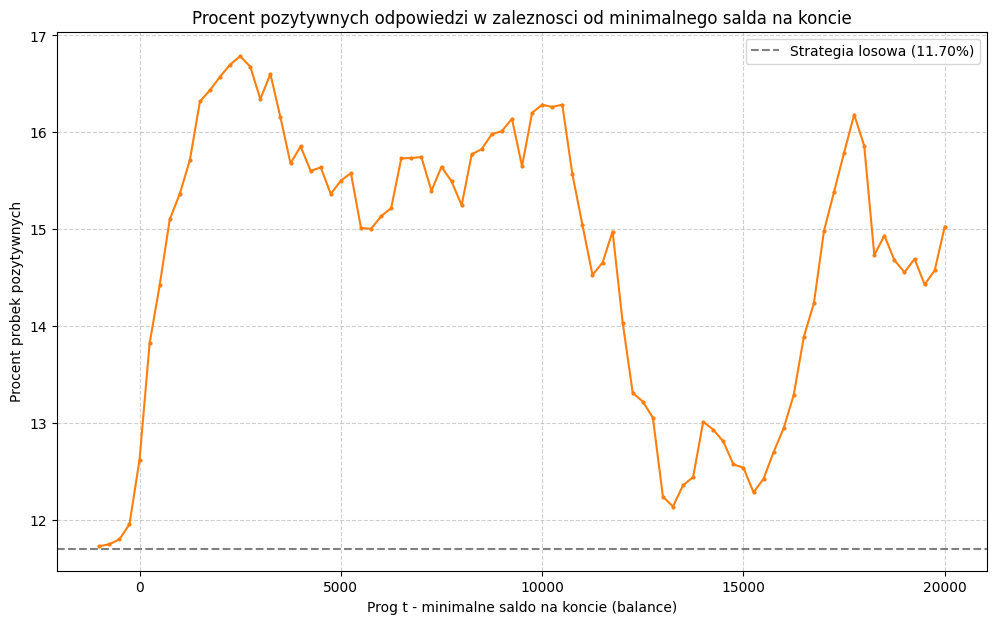

In [166]:
thr = np.arange(-1000, 20001, 250)
perc = []

for t in thr:
    hgh_bal = df[df['balance'] > t]
    if(len(hgh_bal) > 0):
        succ = hgh_bal[hgh_bal['y'] == 'yes']
        prc = ((len(succ) / len(hgh_bal))) * 100
        perc.append(prc)
    else:
        perc.append(np.nan) # not a number

plt.figure(figsize=(12, 7))
plt.plot(thr, perc, marker='.', linestyle='-', markersize=4, color='C1')
plt.title('Procent pozytywnych odpowiedzi w zaleznosci od minimalnego salda na koncie')
plt.xlabel('Prog t - minimalne saldo na koncie (balance)')
plt.ylabel('Procent probek pozytywnych')
plt.grid(True, linestyle='--', alpha=0.6)

baseline_success = (len(df[df['y'] == 'yes']) / len(df)) * 100
plt.axhline(y=baseline_success, color='grey', linestyle='--', label=f'Strategia losowa ({baseline_success:.2f}%)')
plt.legend()
plt.show()



Dobrym wyborem bedzie prog w okolicach 1500 - 3000 (saldo)

zadanie 2.5

In [167]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.5, random_state=42, stratify=df['y'])
# stratify -> w obydwu czesciach podobne ratio odpowiedzi 'yes'/'no'

print(f'Rozmiar setów:\ntreningowy = {len(df_train)}, testowy = {len(df_test)}')
assert(1.02 > (len(df_train) / len(df_test)) > 0.98)

Rozmiar setów:
treningowy = 22605, testowy = 22606


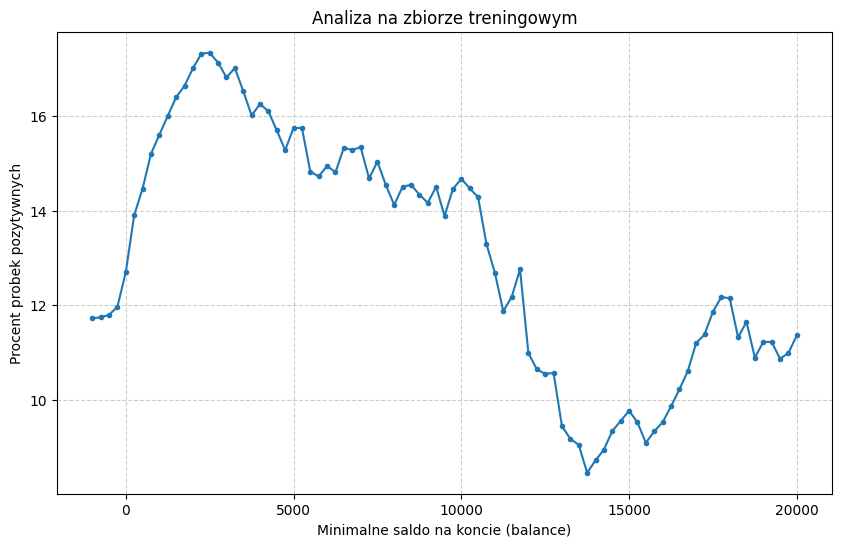

In [168]:
thr = np.arange(-1000, 20001, 250)
perc = []

for t in thr:
    hgh_bal = df_train[df_train['balance'] > t]
    if len(hgh_bal) > 0:
        succ = hgh_bal[hgh_bal['y'] == 'yes']
        perc.append((len(succ) / len(hgh_bal)) * 100)
    else:
        perc.append(np.nan)

plt.figure(figsize=(10, 6))
plt.plot(thr, perc, marker='.', linestyle='-')
plt.title('Analiza na zbiorze treningowym')
plt.xlabel('Minimalne saldo na koncie (balance)')
plt.ylabel('Procent probek pozytywnych')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

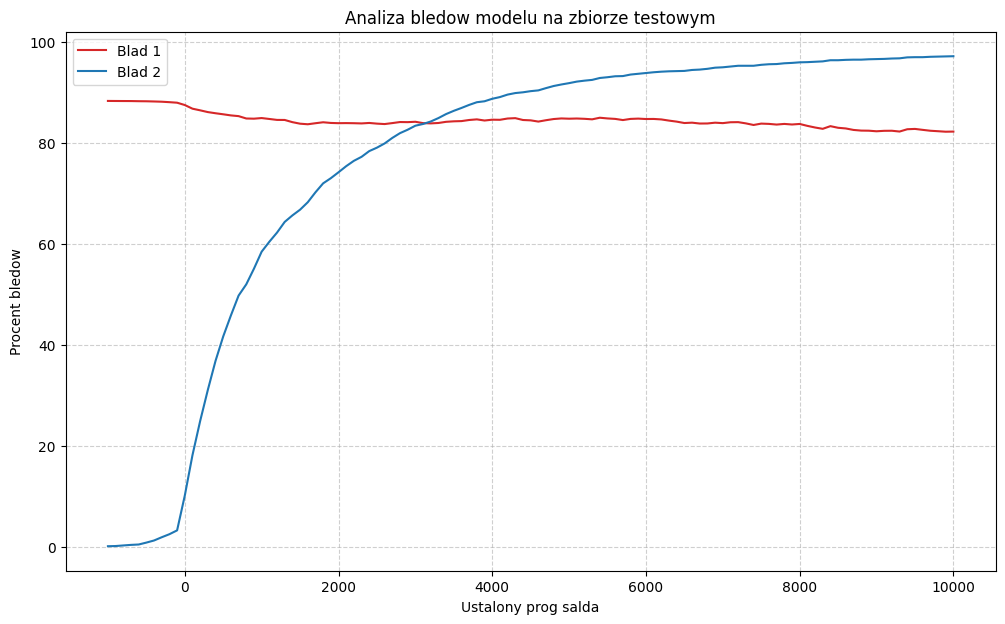

In [169]:

thr = np.arange(-1000, 10001, 100)
e1 = [] # falszywe pozytywy (nasza regula blednie zaklasyfikowala jako "zainteresowanych" (bo mieli za wysokie saldo), a w rzeczywistosci odmowili)
e2 = [] # klienci ktorzy byli zainteresowani ale nasza regula ich pominela, przez saldo

all_yes = len(df_test[df_test['y'] == 'yes'])

for t in thr:
    # typ 1
    pred_yes = df_test[df_test['balance'] > t]
    if len(pred_yes) > 0:
        act_no = pred_yes[pred_yes['y'] == 'no']
        e1_rate = (len(act_no) / len(pred_yes)) * 100
        e1.append(e1_rate)
    else:
        e1.append(np.nan)

    # typ 2
    missed_yes = df_test[(df_test['y'] == 'yes') & (df_test['balance'] <= t)]
    e2_rate = (len(missed_yes) / all_yes) * 100
    e2.append(e2_rate)

plt.figure(figsize=(12, 7))
plt.plot(thr, e1, label='Blad 1', color='C3')
plt.plot(thr, e2, label='Blad 2', color='C0')
plt.title('Analiza bledow modelu na zbiorze testowym')
plt.xlabel('Ustalony prog salda')
plt.ylabel('Procent bledow')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Ustalenie wysokiego progu salda jest złą strategią. Nieznacznie poprawia to 'celnosc' telefonow, ale dzieje sie to kosztem pominiecia prawie wszystkich chetnych klientow.
Najlepszym wyborem bedzie wybor bardzo niskiego progu. Pozwala to zminimalizowac blad 2 (nawet jezeli akceptujemy blad 1).

### Zadanie 3

In [170]:
from ucimlrepo import fetch_ucirepo
# https://archive.ics.uci.edu/dataset/19/car+evaluation
# fetch dataset
car_evaluation = fetch_ucirepo(id=19)

# data (as pandas dataframes)
X = car_evaluation.data.features
Y = car_evaluation.data.targets

# metadata
print(car_evaluation.metadata)

# variable information
print(car_evaluation.variables)


{'uci_id': 19, 'name': 'Car Evaluation', 'repository_url': 'https://archive.ics.uci.edu/dataset/19/car+evaluation', 'data_url': 'https://archive.ics.uci.edu/static/public/19/data.csv', 'abstract': 'Derived from simple hierarchical decision model, this database may be useful for testing constructive induction and structure discovery methods.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1728, 'num_features': 6, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1988, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5JP48', 'creators': ['Marko Bohanec'], 'intro_paper': {'ID': 249, 'type': 'NATIVE', 'title': 'Knowledge acquisition and explanation for multi-attribute decision making', 'authors': 'M. Bohanec, V. Rajkovič', 'venue': '8th Intl Workshop on Expert Systems and their Applications, 

6 atrybutów:
-> buying (cena zakupu)
-> maint  (koszt utrzymania)
-> doors  (liczba drzwi)
-> persons (pojemnosc osob)
-> lug_boot (rozmiar bagaznika)
-> safety (szacowane bezpieczenstwo)

Cel -> przypisanie samochodu do jednej z czterech klas oceny
unacc, acc, good, vgood


zadanie 3.1


class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


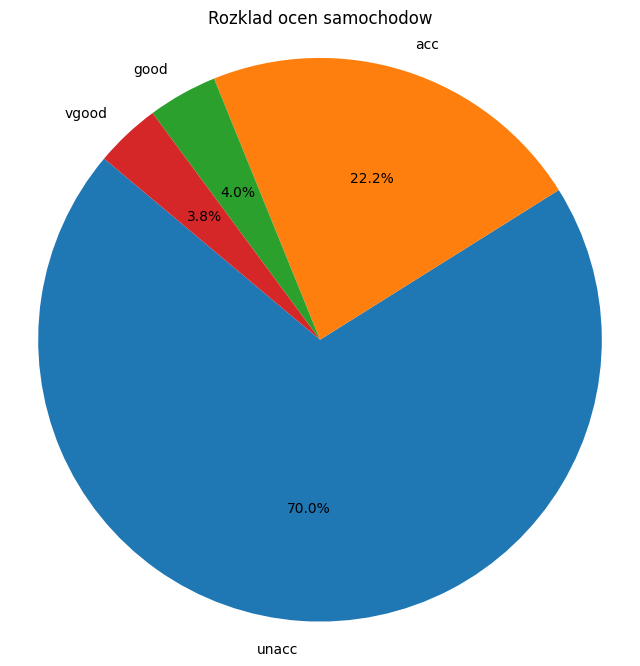

In [171]:
df = pd.concat([X, Y], axis = 1)

class_counts = df['class'].value_counts()
print(class_counts)

plt.figure(figsize=(8, 8))
plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Rozklad ocen samochodow')
plt.axis('equal')
plt.show()

zadanie 3.2

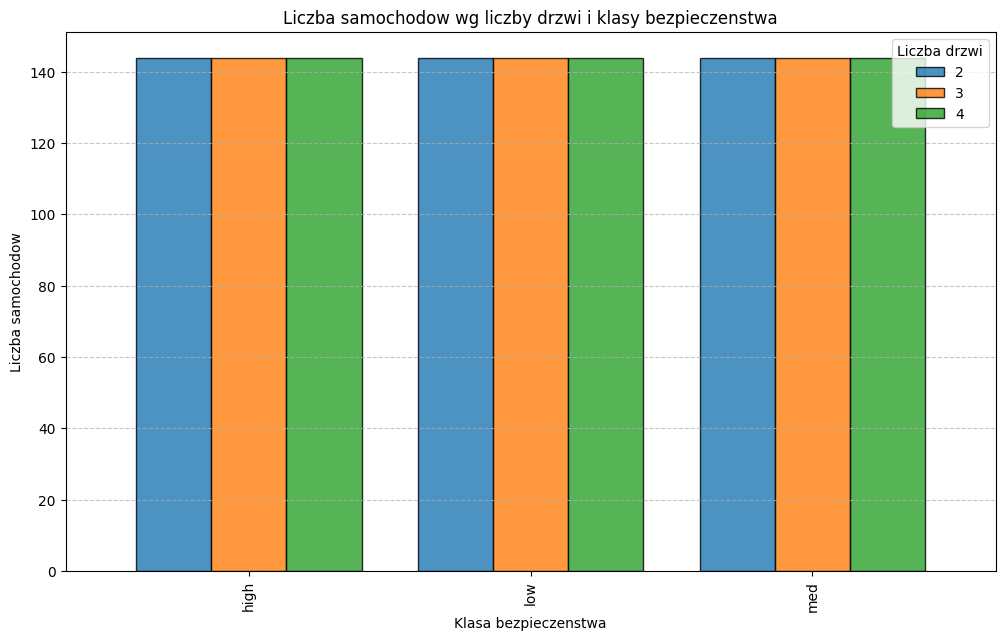

In [172]:
doors = ['2', '3', '4']
df_doors = df[df['doors'].isin(doors)] # filtrowanie danych

cnt = pd.crosstab(df_doors['safety'], df_doors['doors'])
#print(cnt)

labels = cnt.index # (low, med, high -> etykiety dla OX)

ax = cnt.plot(
    kind = 'bar',
    figsize=(12, 7),
    width=0.8,
    edgecolor = 'k',
    alpha=0.8
)

ax.set_ylabel('Liczba samochodow')
ax.set_xlabel('Klasa bezpieczenstwa')
ax.set_title('Liczba samochodow wg liczby drzwi i klasy bezpieczenstwa')
ax.legend(title='Liczba drzwi')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Zadanie 4

zadanie 4.1

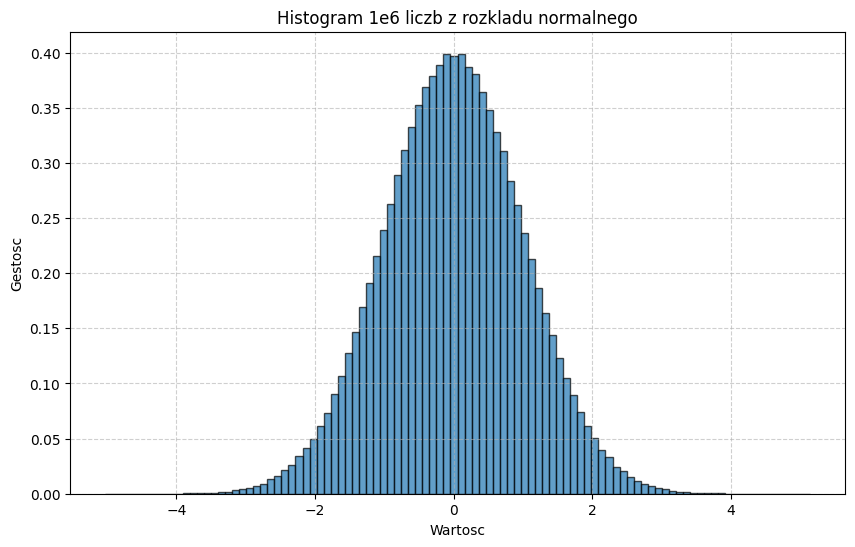

In [173]:
data = np.random.randn(1000000)
#print(data)

plt.figure(figsize=(10, 6))
plt.hist(data, bins=100, density=True, color='C0', edgecolor='k', alpha=0.7)
plt.title('Histogram 1e6 liczb z rozkladu normalnego')
plt.xlabel('Wartosc')
plt.ylabel('Gestosc')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


zadanie 4.2

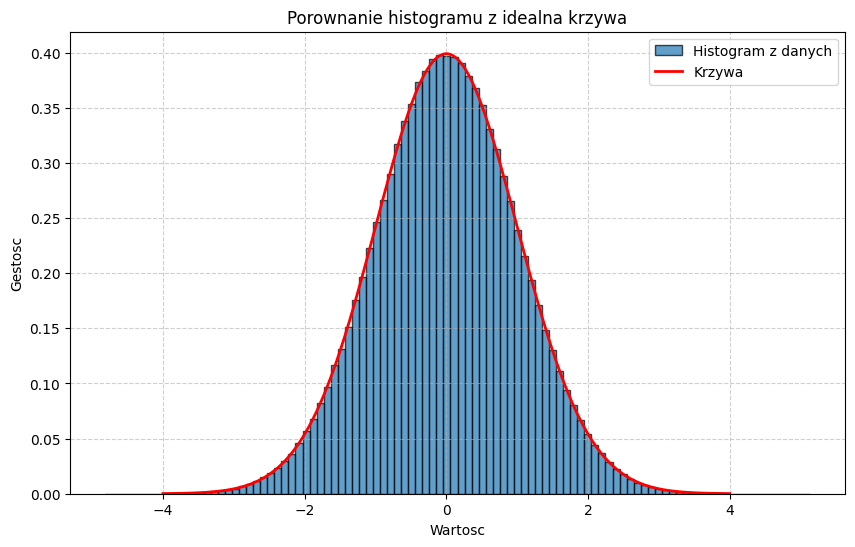

In [174]:
data = np.random.randn(1000000)
#print(data)

plt.figure(figsize=(10, 6))
plt.hist(data, bins=100, density=True, color='C0', edgecolor='k', alpha=0.7, label = 'Histogram z danych')

from scipy.stats import norm

x_axis = np.arange(-4, 4, 0.001)
plt.plot(x_axis, norm.pdf(x_axis), color='red', linewidth=2, label='Krzywa')

plt.title('Porownanie histogramu z idealna krzywa')
plt.xlabel('Wartosc')
plt.ylabel('Gestosc')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

zadanie 4.3

In [175]:
iris = fetch_ucirepo(id=53)

X = iris.data.features
Y = iris.data.targets
df = pd.concat([X, Y], axis = 1)

s = 0.25
df_noisy = df.copy()

df_noisy['sepal length'] += np.random.normal(loc=0, scale=s, size=len(df))
df_noisy['sepal width'] += np.random.normal(loc=0, scale=s, size=len(df))

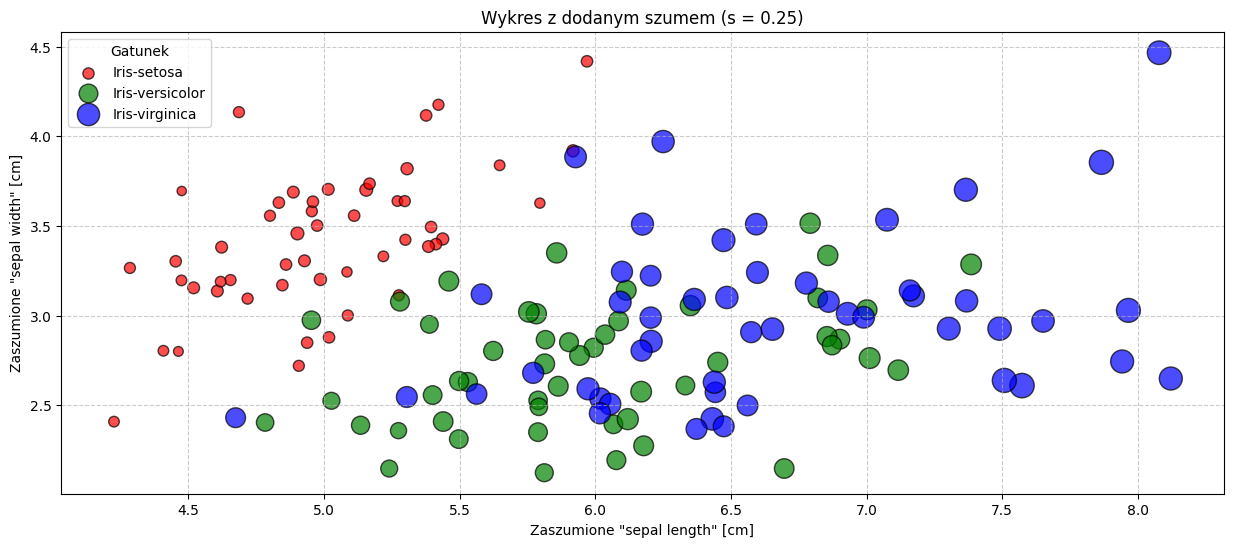

In [176]:
colors = {'Iris-setosa' : 'red', 'Iris-versicolor' : 'green', 'Iris-virginica' : 'blue'}
plt.figure(figsize=(15, 6))

for g in df_noisy['class'].unique():
    subset = df_noisy[df_noisy['class'] == g]
    plt.scatter(
        subset['sepal length'],
        subset['sepal width'],
        s=subset['petal length']*45,
        c=colors[g],
        alpha=0.7,
        edgecolor='k',
        label=g
    )

plt.xlabel('Zaszumione "sepal length" [cm]')
plt.ylabel('Zaszumione "sepal width" [cm]')
plt.title(f'Wykres z dodanym szumem (s = {s})')
plt.legend(title='Gatunek')
plt.grid(True, linestyle='--', alpha=0.65)
plt.show()

Jak zmienia sie wykres? Bardzo podobny do oryginalnego, ale punkty sa odrobine bardziej rozproszone. Kazdy punkt zostal lekko przesuniety w losowym kierunku.
Regula odrozniania, ze na lewo (czerwone) to setosa, nadal działa.
Jednak ciezej nieco jest z odroznieniem niebieskich i zielonych punktow.

### Zadanie 5

zadanie 5.1 , 5.2